# Final Project Phase 3 Summary
This Jupyter Notebook (.ipynb) will serve as the skeleton file for your submission for Phase 3 of the Final Project. Complete all sections below as specified in the instructions for the project, covering all necessary details. We will use this to grade your individual code (Do this whether you are in a group or not). Good luck! <br><br>

Note: To edit a Markdown cell, double-click on its text.

Submission Info:
* Members: Jackson O'Connell, Sushanth Chunduri
* Course: CS 2316 Section A
* Term: Fall 2025
* Canvas Team: #131
* Assigned TA: Sid

## Jupyter Notebook Quick Tips
Here are some quick formatting tips to get you started with Jupyter Notebooks. This is by no means exhaustive, and there are plenty of articles to highlight other things that can be done. We recommend using HTML syntax for Markdown but there is also Markdown syntax that is more streamlined and might be preferable. 
<a href = "https://towardsdatascience.com/markdown-cells-jupyter-notebook-d3bea8416671">Here's an article</a> that goes into more detail. (Double-click on cell to see syntax)

# Heading 1
## Heading 2
### Heading 3
#### Heading 4
<br>
<b>BoldText</b> or <i>ItalicText</i>
<br> <br>
Math Formulas: $x^2 + y^2 = 1$
<br> <br>
Line Breaks are done using br enclosed in < >.
<br><br>
Hyperlinks are done with: <a> https://www.google.com </a> or 
<a href="http://www.google.com">Google</a><br>

# Video Presentation

If you uploaded your Video Presentation to Bluejeans, YouTube, or any other streaming services, please provide the link here:


*   Video Presentation Link


Make sure the video sharing permissions are accessible for anyone with the provided link.

In [18]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import regex as re
import requests
import json
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from datetime import datetime
from bs4 import BeautifulSoup as bs4

# URLs, Paths & API Keys:
CPI_URL = "https://fred.stlouisfed.org/data/CPIAUCSL"
EIA_BASE_URL = "https://api.eia.gov/v2/petroleum/pri/spt/data/"
EIA_API_KEY = "gc3m0emd44qaMHTNQxwmLqupbzdCtHHB2G6aOCNl"
oil_export_path = "eia_wti_quarterly.csv"
raw_cpi_export_path = "cpi_raw.csv"
clean_cpi_export_path = "cpi_clean.csv"
baggage_path = 'BaggageFees.xlsx'

pd.set_option('future.no_silent_downcasting', True)

# Data Collection and Cleaning


Transfer/update the data collection and cleaning you created for Phase II below. You may include additional cleaning functions if you have extra datasets. If no changes are necessary, simply copy and paste your phase II parsing/cleaning functions.


## Downloaded Dataset Requirement



In [19]:
airfares = pd.read_csv("ConsumerAirfares.csv")

# Drops columns that are duplicates or unnecessary
airfares = airfares.drop(["table_1_flag","Geocoded_City1","Geocoded_City2","Geocoded_City1 (city)","Geocoded_City2 (city)"],axis=1)

### Inconsistency: Fill necessary columns with missing values that have NaN values with 0
airfares["lf_ms"] = airfares["lf_ms"].fillna(0)
airfares["carrier_low"] = airfares["carrier_low"].fillna(0)
airfares["fare_low"] = airfares["fare_low"].fillna(0)
airfares = airfares.dropna(axis=1)

### Inconsistency: citymarketid_1 was a object with commas whereas citymarketid_2 was a column of ints, changed citymarketid_1 to be column of ints
airfares["citymarketid_1"] = airfares["citymarketid_1"].str.replace(',','').astype(int)

### Somewhat inconsistencies: changed passengers, fare, fare_large, fare_low to be integers or floats rounded to two decimal points to make calculations easier in the future
airfares["passengers"] = airfares["passengers"].astype(str).str.replace(',', '').astype(int)
airfares["fare"] = round(airfares["fare"].astype(str).str.replace('$','').astype(float),2)
airfares["fare_lg"] = round(airfares["fare_lg"].astype(str).str.replace('$','').astype(float),2)
airfares["fare_low"] = round(airfares["fare_low"].astype(str).str.replace('$','').astype(float),2)

airfares

,Year,quarter,citymarketid_1,citymarketid_2,city1,city2,nsmiles,passengers,fare,carrier_lg,large_ms,fare_lg,carrier_low,lf_ms,fare_low
0,2025,2,32467,31703,"Miami, FL (Metropolitan Area)","New York City, NY (Metropolitan Area)",1118,17955,208.52,B6,0.2551,191.48,B6,0.2551,191.48
1,2025,2,32575,32457,"Los Angeles, CA (Metropolitan Area)","San Francisco, CA (Metropolitan Area)",372,17310,157.68,WN,0.5006,169.03,AS,0.1193,140.59
2,2025,2,32575,31703,"Los Angeles, CA (Metropolitan Area)","New York City, NY (Metropolitan Area)",2510,13648,430.38,DL,0.2535,526.21,B6,0.2272,365.63
3,2025,2,31703,31454,"New York City, NY (Metropolitan Area)","Orlando, FL",989,12627,186.50,B6,0.3735,186.10,B6,0.3735,186.10
4,2025,2,30977,31703,"Chicago, IL","New York City, NY (Metropolitan Area)",773,11284,221.33,UA,0.4328,238.62,AA,0.2426,217.36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118030,1996,1,33495,31454,"New Orleans, LA","Orlando, FL",550,111,138.88,DL,0.2600,174.49,NW,0.1400,112.40
118031,1996,1,30647,31995,"Cleveland, OH (Metropolitan Area)","Greensboro/High Point, NC",381,111,199.92,CO,0.8400,193.76,CO,0.8400,193.76
118032,1996,1,30158,31454,"Atlantic City, NJ","Orlando, FL",852,111,95.23,NK,0.9300,91.49,NK,0.9300,91.49
118033,1996,1,33244,33495,"Memphis, TN","New Orleans, LA",349,110,201.52,NW,0.8800,204.78,J7,0.0400,121.56


# Additional Dataset: 

In [20]:
def row_contains_keyword(row, keywords):
    #Check if a row contains keywords, which are likely column names.
    vals = [("" if pd.isna(v) else str(v).strip().lower()) for v in row.values]
    return any(word.lower() in v for v in vals for word in keywords)

def find_header_row(df):
    #Finds the row number that's probably the header
    keywords = ['rank', 'airline', '1Q', '2Q', '3Q', '4Q']
    for i, row in df.iterrows():
        if row_contains_keyword(row, keywords):
            non_empty = sum(1 for v in row.values if not pd.isna(v) and str(v).strip() != '')
            if non_empty >= 2:
                return i
    return None

def clean_dataframe(df):
    # Strip column names
    df.columns = [("" if pd.isna(x) else str(x).strip()) for x in df.columns]

    # Remove empty columns
    df = df.dropna(axis=1, how='all')

    # Find airline column
    key_col = None
    for col in df.columns:
        if 'airline' in str(col).strip().lower():
            key_col = col
            break

    # Remove rows with empty airline column
    if key_col:
        df = df[df[key_col].notna()]
        df.reset_index(drop=True, inplace=True)

    return df

# Dictionary to store all cleaned DataFrames
all_sheets = {}

baggage = pd.ExcelFile(baggage_path)

# Filter sheets from 2007 to 2025
sheets = [s for s in baggage.sheet_names if re.match(r'^(2007|2008|2009|201\d|202[0-5])$', s)]

for sheet_name in sheets:
    # Read to get row that's probably header
    df = pd.read_excel(baggage, sheet_name=sheet_name, header=None, dtype=object)
    
    header_row = find_header_row(df)
    
    # Now look at it now we know the header
    df = pd.read_excel(baggage, sheet_name=sheet_name, header=header_row, dtype=object)
    
    df = clean_dataframe(df)
    
    all_sheets[sheet_name] = df
    print(sheet_name)
    print(df.head(), "\n")


for sheet_name in all_sheets:
    if(sheet_name == '2025'):
        break;
    df = all_sheets[sheet_name]
    df = df.dropna() 
    all_sheets[sheet_name] = df.reset_index(drop=True)

for sheet_name in all_sheets: 
    all_sheets[sheet_name].drop('Rank', axis=1, errors='ignore', inplace=True)
    print(sheet_name)
    print(all_sheets[sheet_name])

for sheet_name, df in all_sheets.items():
    cols = [col for col in df.columns if str(col).strip().upper() in ['1Q', '2Q', '3Q', '4Q','Full Year']]
    
    for col in cols:
        df[col] = df[col].replace(['-', None], 0).astype(float)


for sheet_name in sheets:
    print(sheet_name)
    print(all_sheets[sheet_name].head())

############ Function Call ############


2007
  Rank               Airline     1Q     2Q     3Q     4Q Full Year
0    1   American Airlines    28829  30015  31346  34348    124538
1    2     Delta Air Lines    20343  22447  25035  28721     96546
2    3       United Airlines  12045  13410  14829  12718     53002
3    4  Continental Airlines  10715  11045  10565  10519     42844
4    5  Northwest Airlines     8339   8956   9897  10309     37501 

2008
  Rank               Airline     1Q     2Q     3Q      4Q Full Year
0    1   American Airlines    32959  37101  94075  113856    277991
1    2         US Airways      7478  17917  67928   93759    187082
2    3     Delta Air Lines    26571  42461  47489   60542    177063
3    4       United Airlines  12219  19721  42283   58771    132994
4    5  Northwest Airlines     9641  15685  32695   63578    121599 

2009
  Rank               Airline      1Q      2Q      3Q      4Q Full Year
0    1     Delta Air Lines    102838  118356  129465  131060    481719
1    2   American Airlines   

## Web Collection Requirement \#1


In [21]:
# Note: Pylance errors because the skeleton template puts the helper functions below this block, so make sure to run those before this.

def get_quarterly_cpi(raw_path=raw_cpi_export_path,clean_path=clean_cpi_export_path,data_url=CPI_URL,base_year=2025,silence=False):
    html = requests.get(data_url).text
    soup = bs4(html, "html.parser")
    table = soup.find("table", id="data-table-observations")
    if not table:
        raise ValueError("CPI table not found; check HTML structure")

    rows = []
    tbody = table.find("tbody")
    for tr in tbody.find_all("tr"):
        th = tr.find("th")
        tds = tr.find_all("td")
        if not th or not tds:
            continue
        rows.append((th.get_text().strip(), tds[0].get_text().strip()))

    cpi = pd.DataFrame(rows, columns=["date","value"])
    cpi["date"]  = pd.to_datetime(cpi["date"])
    cpi["value"] = pd.to_numeric(cpi["value"])
    cpi = cpi.dropna().sort_values("date").reset_index(drop=True)
    
    if not silence:
        save_csv(cpi, raw_path)
    else:
        save_csv(cpi,raw_path,silence=silence)

    cpi["qstart"] = cpi["date"].dt.to_period("Q").dt.start_time
    cpi_q = (cpi.groupby("qstart",as_index=False)["value"]
               .mean()
               .rename(columns={"qstart":"quarter_start_date","value":"cpi_index"}))
    cpi_q["quarter"] = cpi_q["quarter_start_date"].apply(to_quarter_label)

    q = cpi_q["quarter"].astype(str)
    m = q.str.startswith(str(base_year))
    base = cpi_q[m].iloc[-1] if m.any() else cpi_q.iloc[-1]

    # using .copy() to start clean, not technically needed though. Also good for splitting nom vs real $.
    out = cpi_q[["quarter","cpi_index"]].copy()
    out["cpi_base_year"] = base_year
    out["cpi_base_value"] = float(base["cpi_index"])
    out["cpi_base_quarter_used"] = str(base["quarter"])

    if not silence:
        save_csv(out, clean_path)
    else:
        save_csv(out, clean_path,silence=silence)

    return out


############ Function Call ############
get_quarterly_cpi()


rewrote cpi_raw.csv
rewrote cpi_clean.csv


,quarter,cpi_index,cpi_base_year,cpi_base_value,cpi_base_quarter_used
0,1947Q1,21.700000,2025,323.288,2025Q3
1,1947Q2,22.010000,2025,323.288,2025Q3
2,1947Q3,22.490000,2025,323.288,2025Q3
3,1947Q4,23.126667,2025,323.288,2025Q3
4,1948Q1,23.616667,2025,323.288,2025Q3
...,...,...,...,...,...
310,2024Q3,314.182667,2025,323.288,2025Q3
311,2024Q4,316.538667,2025,323.288,2025Q3
312,2025Q1,319.492000,2025,323.288,2025Q3
313,2025Q2,320.800333,2025,323.288,2025Q3


## Web Collection Requirement #2

In [22]:
def get_eia_data(cpi_df=get_quarterly_cpi(silence=True), base=EIA_BASE_URL, api_key=EIA_API_KEY,export_path=oil_export_path):
    params = {
        "api_key": api_key,
        "frequency": "monthly",
        "data[0]": "value",
        "length": 5000,
        "start": "2000-01-01"
    }
    r = requests.get(base, params=params)
    parsed = json.loads(r.text)

    rows = []
    if isinstance(parsed, dict): # checks object is a dict format, throws error print message if format changes
        rows = parsed["response"]["data"]

    eia = pd.DataFrame(rows)

    if eia.empty:
        return "Not working, data is empty."
    
    eia = eia[eia["series"].eq("RWTC")] # mask Boolean indexing to get only WTI spot prices
    # Note: RWTC is the specific WTI provided spot price name that seems to be best for aviation purposes based on what we researched

    eia["value"] = pd.to_numeric(eia.get("value", np.nan))

    eia["period"] = pd.to_datetime(eia["period"])
    eia["value"] = pd.to_numeric(eia.get("value", np.nan))
    eia = eia.dropna(subset=["period", "value"])

    # monthly -> quarterly mean
    eia["qstart"] = eia["period"].dt.to_period("Q").dt.start_time
    eia["qstart"] = eia["period"].dt.to_period("Q").dt.start_time
    wti_q = (
        eia.groupby("qstart", as_index=False)["value"]
           .mean()
           .rename(columns={"qstart": "quarter_start_date", "value": "wti_usd_nominal"})
    )
    wti_q["quarter"] = wti_q["quarter_start_date"].apply(to_quarter_label)

    cpi_small = cpi_df[["quarter", "cpi_index", "cpi_base_value"]].copy()
    merged = wti_q.merge(cpi_small, on="quarter", how="left")
    
    merged["wti_usd_real"] = merged["wti_usd_nominal"] * (merged["cpi_base_value"] / merged["cpi_index"])

    eia_clean = merged[["quarter", "wti_usd_nominal", "wti_usd_real"]].sort_values("quarter").reset_index(drop=True)
    save_csv(eia_clean, export_path)

    return eia_clean

# Additional Functions

In [23]:
# date formatting function
def to_quarter_label(ts):
    q = ((ts.month - 1) // 3) + 1
    return f"{ts.year}Q{q}"

# save csv function
def save_csv(df, path, silence=False):
    df.to_csv(path, index=False)
    if not silence:
        print(f"rewrote {path}")
    
# test
print(to_quarter_label(datetime(2025, 2, 15)))

2025Q1


# Merging datasets additional cleaning for analysis

In [24]:
# load cleaned datasets from Phase II
cpi_df = pd.read_csv("cpi_clean.csv")
oil_df = pd.read_csv("eia_clean.csv")

# merge CPI and oil data on quarter
base_df = cpi_df.merge(oil_df, on='quarter')

# helper function for making quarter labels
def to_quarter_label(ts):
    q = ((ts.month - 1) // 3) + 1
    return f"{ts.year}Q{q}"

# Build quarterly airfare dataset
airfare = pd.read_csv("ConsumerAirfares.csv")

# make quarter col
airfare['quarter'] = airfare['Year'].astype(str) + 'Q' + airfare['quarter'].astype(str)

# clean $ and commas
airfare['passengers'] = airfare['passengers'].astype(str).str.replace(',', '').astype(int)
airfare['fare'] = airfare['fare'].astype(str).str.replace('$', '').astype(float)

# calc weighted avg fare by quarter
airfare_q = airfare.groupby('quarter').apply(
    lambda x: pd.Series({
        'avg_domestic_fare': (x['fare'] * x['passengers']).sum() / x['passengers'].sum(),
        'total_passengers': x['passengers'].sum()
    })
).reset_index()

# Build quarterly baggage fee dataset

# helper functions from BaggageCleaner approach
def row_contains_keyword(row, keywords):
    vals = [("" if pd.isna(v) else str(v).strip().lower()) for v in row.values]
    return any(word.lower() in v for v in vals for word in keywords)

def find_header_row(df):
    keywords = ['rank', 'airline', '1q', '2q', '3q', '4q']
    for i, row in df.iterrows():
        if row_contains_keyword(row, keywords):
            non_empty = sum(1 for v in row.values if not pd.isna(v) and str(v).strip() != '')
            if non_empty >= 2:
                return i
    return None

# load baggage data
baggage_file = pd.ExcelFile('BaggageFees.xlsx')
year_sheets = [s for s in baggage_file.sheet_names if re.match(r'^(200\d|201\d|202[0-5])$', s)]
baggage_rows = []

# process each year sheet
for year in year_sheets:
    df = pd.read_excel(baggage_file, sheet_name=year, header=None, dtype=object)
    header_row = find_header_row(df)
    
    if header_row is None:
        continue
    
    df = pd.read_excel(baggage_file, sheet_name=year, header=header_row, dtype=object)
    df.columns = [("" if pd.isna(x) else str(x).strip()) for x in df.columns]
    
    airline_col = None
    for col in df.columns:
        if 'airline' in col.lower():
            airline_col = col
            break
    
    if airline_col is None and len(df.columns) > 1:
        airline_col = df.columns[1]
    
    if airline_col is None:
        continue
    
    q_cols = [c for c in df.columns if str(c).strip().upper() in ['1Q', '2Q', '3Q', '4Q']]
    
    if not q_cols:
        continue
    
    for idx, row in df.iterrows():
        airline = row[airline_col]
        if pd.isna(airline) or str(airline).strip() == '':
            continue
        
        for q_col in q_cols:
            val = row[q_col]
            if pd.isna(val) or val == '-':
                val = 0
            else:
                try:
                    val = float(str(val).replace(',', ''))
                except:
                    val = 0
            
            q_num = q_col.strip()[0]
            quarter = f"{year}Q{q_num}"
            baggage_rows.append({
                'quarter': quarter,
                'airline': str(airline).strip(),
                'baggage_fees': val
            })

baggage_long = pd.DataFrame(baggage_rows)
baggage_q = baggage_long.groupby('quarter')['baggage_fees'].sum().reset_index()
baggage_q.columns = ['quarter', 'total_baggage_fees']

# load dataset_a for insights
dataset_a = pd.read_csv('dataset_a_quarterly.csv')

/var/folders/cj/08jgvgj1415fj07lknvrgrnm0000gn/T/ipykernel_36420/4211444526.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  airfare_q = airfare.groupby('quarter').apply(


## Data Sources

Include sources (as links) to your datasets. If any of these are different from your sources used in Phase II, please <b>clearly</b> specify.


*   Downloaded Dataset #1 Source (Excel): 
    *   <a href="https://www.bts.gov/baggage-fees">Bureau of Transportation Aviation Statistics for Baggage Fees (All Years)</a><br>
    *   <a href="https://www.bts.gov/topics/airlines-and-airports/baggage-fees-airline-2025">BTS Baggage Fees Data (2025 + All Years) </a><br>
    *   Baggage Fees by Airline and Year (Excel file)
*   Downloaded Dataset #2 Source (CSV):
    *   <a href="https://www.transportation.gov/policy/aviation-policy/domestic-airline-consumer-airfare-report">BTS Domestic Consumer Airfare Data (Table 1)</a><br>
    *   <a href="https://data.transportation.gov/Aviation/Consumer-Airfare-Report-Table-2-Top-1-000-City-Pai/wqw2-rjgd/about_data">BTS Consumer Airfare Table 1 Data Specifics</a><br>
    *   Airfare prices and city pairs (CSV file)
*   Web Collection #1 Source (Web Scraping/bs4):
    *   <a href="https://fred.stlouisfed.org/data/CPIAUCSL">FRED CPI Data</a><br>
    *   FRED (Govt economics database) CPI data website BeautifulSoup scraping
*   Web Collection #2 Source (API/JSON):
    *  <a href="https://api.eia.gov/v2/petroleum/pri/spt/data/">EIA API Endpoint</a><br>
    *  EIA Petroleum (WTI RWTC specifically)

# Data Analysis
For the Data Analysis section, you are required to utilize your data to complete the following:

*   Create at least 5 insights
*   Generate at least 3 data visualizations

Create a function for each of the following sections mentioned above. Do not forget to fill out the explanation section for each function. 

Make sure your data analysis is not too simple. Performing complex aggregation and using modules not taught in class shows effort, which will increase the chance of receiving full credit. 

# Topic Summary

This project analyzes the relationship between real airfare costs and real baggage revenue. We utilized data collected about airfares and baggage fees from the BTS (Bureau of Transportation Statistics), oil prices from the U.S. Energy Information Administration, and CPI data from the Federal Reserve (CPI). We get this data from 2010 to 2025 into one dataset with inflation, oil price, baggage fee, and airfare data to find trends in the data. The primary objective was to determine the economic drivers behind airfare pricing and ancillary revenue growth. Using Linear and Polynomial Regression, alongside a Random Forest Regressor for feature importance, we analyzed the impact of fuel costs (WTI Oil Price), passenger demand, and non-fare revenue on average ticket price. 

## Insights

In [ ]:
# Insight 1: Oil vs Airfare Prediction using Linear Regression
print("=== Insight 1: Predicting Airfare from Oil Prices (sklearn) ===")

# train linear regression model to see if oil prices predict airfares
# split into train/test to avoid overfitting

# prepare data for sklearn - need to reshape for model
X = dataset_a[['wti_real_2025']].values  # features (oil price)
y = dataset_a['avg_domestic_fare'].values  # target (airfare)

# split data into training and testing sets (80/20 split)
# random_state=42 makes results reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# create and train linear regression model on TRAINING data only
model = LinearRegression()
model.fit(X_train, y_train)

# make predictions on TEST data (unseen during training)
y_pred = model.predict(X_test)

# evaluate model on test set
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Linear Regression Results (on test set):")
print(f"Coefficient (slope): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.2f}")
print(f"R^2 score: {r2:.4f}")
print(f"RMSE: ${rmse:.2f}")

# test prediction: what fare for $100 oil?
test_oil = np.array([[100]])
predicted_fare = model.predict(test_oil)[0]
print(f"\nPrediction: At $100/barrel oil, avg domestic fare = ${predicted_fare:.2f}")

# find periods of high vs low oil
high_oil = dataset_a[dataset_a['wti_real_2025'] > dataset_a['wti_real_2025'].median()]
low_oil = dataset_a[dataset_a['wti_real_2025'] <= dataset_a['wti_real_2025'].median()]

print(f"\nAvg fare during high oil periods: ${high_oil['avg_domestic_fare'].mean():.2f}")
print(f"Avg fare during low oil periods: ${low_oil['avg_domestic_fare'].mean():.2f}")
print(f"Difference: ${high_oil['avg_domestic_fare'].mean() - low_oil['avg_domestic_fare'].mean():.2f}")

print("\nInsight: Estimated positive slope, but low predictive power")
print(f"Airfares increase by about ${model.coef_[0]:.2f} for every $1 increase in oil prices.")
print(f"However, R^2 is {r2:.4f}, indicating the model performs worse than baseline prediction.")

=== Insight 1: Predicting Airfare from Oil Prices (sklearn) ===
Linear Regression Results (on test set):
  Coefficient (slope): 0.1175
  Intercept: 197.00
  R^2 score: -0.1569
  RMSE: $18.07

Prediction: At $100/barrel oil, avg domestic fare = $208.76

Avg fare during high oil periods: $209.85
Avg fare during low oil periods: $207.23
Difference: $2.62

Insight: Estimated positive slope, but low predictive power
Airfares increase by about $0.12 for every $1 increase in oil prices.
However, R^2 is -0.1569, indicating the model performs worse than baseline prediction.


### Insight 1 Explanation

This function uses a Linear Regression model to predict average domestic airfares based on real WTI oil prices. The model was trained on 80% of the data and tested on the remaining 20% to avoid overfitting. The coefficient indicates how much airfares change per dollar increase in oil prices. However, the R^2 score is negative, which means the model performs worse than just using the mean airfare as a prediction. This suggests that oil prices alone don't explain airfare variation well, and other factors like demand, seasonality, or competition are probably more important.

In [ ]:
# Insight 2: baggage revenue vs oil (polynomial regression)
print("=== Insight 2: Baggage vs Oil sklearn polynomial ===")

# using polynomial regression (degree 2) bc the relationship might be curved
# train/test split to check if it actually predicts well

# using polynomial instead of linear bc the relationship might be curved

X = dataset_a[['wti_real_2025']].values
y = dataset_a['total_baggage_fees'].values

# split data into training and testing sets (80/20 split)
# random_state=42 makes results reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# degree 2 polynomial
degree = 2
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())

# train on TRAINING data only
poly_model.fit(X_train, y_train)

# make predictions on TEST data (unseen during training)
y_pred = poly_model.predict(X_test)

# evaluate model on test set
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Polynomial degree {degree} results (on test set):")
print(f"R^2: {r2:.4f}")
print(f"RMSE: ${rmse:.0f}k")

test_prices = np.array([[50], [75], [100], [125]])
predictions = poly_model.predict(test_prices)
print("\nPredictions at different oil prices:")
for price, pred in zip(test_prices.flatten(), predictions):
    print(f"  ${price}/barrel -> ${pred:.0f}k baggage revenue")

early_years = dataset_a[dataset_a['quarter'] <= "2015Q1"]
recent_years = dataset_a[dataset_a['quarter'] > "2015Q1"]

early_avg = early_years['total_baggage_fees'].mean()
recent_avg = recent_years['total_baggage_fees'].mean()

print(f"\nEarly period avg baggage: ${early_avg:.0f}k")
print(f"Recent period avg baggage: ${recent_avg:.0f}k")
print(f"Growth in baggage fees between periods")

=== Insight 2: Baggage vs Oil sklearn polynomial ===
Polynomial degree 2 results (on test set):
  R^2: 0.5037
  RMSE: $581762k
  simple correlation: -0.2798

Predictions at different oil prices:
  $50/barrel -> $1803027k baggage revenue
  $75/barrel -> $2696364k baggage revenue
  $100/barrel -> $2832306k baggage revenue
  $125/barrel -> $2210853k baggage revenue

polynomial model (R^2=0.5037) fits better than linear correlation (-0.2798)

2010-2015 avg baggage: $1722437k
2016+ avg baggage: $2704335k
Growth: $981898k


### Insight 2 Explanation

This function applies a Polynomial Regression (degree 2) to model the relationship between oil prices and total baggage revenue. The model was trained on 80% of the data and tested on 20% to avoid overfitting. The polynomial model captures non-linear relationships better than a simple linear model. The R² score indicates how well oil prices explain variation in baggage fees. Even with the polynomial approach, a significant portion of baggage fee variation remains unexplained by oil prices alone, suggesting other factors like airline policy changes, passenger behavior, and time trends are probably important too.

In [27]:
# Insight 3: Seasonal Fare Pattern Analysis with Visualization
print("=== Insight 3: Seasonal Airfare Pattern Analysis ===") 

# extract quarter number (1, 2, 3, 4)
dataset_a['quarter_num'] = dataset_a['quarter'].str[-1].astype(int)

# calc avg fare by quarter number
seasonal_stats = dataset_a.groupby('quarter_num')['avg_domestic_fare'].agg(['mean', 'std', 'count'])
seasonal_stats.index = ['Q1 (Jan-Mar)', 'Q2 (Apr-Jun)', 'Q3 (Jul-Sep)', 'Q4 (Oct-Dec)']

print("\nAverage Fare by Quarter:")
print(seasonal_stats)

# find highest and lowest
max_q = seasonal_stats['mean'].idxmax()
min_q = seasonal_stats['mean'].idxmin()
print(f"\nHighest avg fare: {max_q} at ${seasonal_stats.loc[max_q, 'mean']:.2f}")
print(f"Lowest avg fare: {min_q} at ${seasonal_stats.loc[min_q, 'mean']:.2f}")
print(f"Seasonal variance: ${seasonal_stats['mean'].max() - seasonal_stats['mean'].min():.2f}")

# clean up temp col
dataset_a = dataset_a.drop('quarter_num', axis=1)

=== Insight 3: Seasonal Airfare Pattern Analysis ===

Average Fare by Quarter:
                    mean        std  count
Q1 (Jan-Mar)  207.711199  19.233887     16
Q2 (Apr-Jun)  212.428288  19.068509     16
Q3 (Jul-Sep)  205.150609  17.894058     15
Q4 (Oct-Dec)  208.676324  19.996853     15

Highest avg fare: Q2 (Apr-Jun) at $212.43
Lowest avg fare: Q3 (Jul-Sep) at $205.15
Seasonal variance: $7.28


### Insight 3 Explanation

This function aggregates average airfares by quarter to identify seasonal trends. The output shows which quarter has the highest and lowest average fares along with the seasonal variance. The seasonal variance is relatively small compared to average fares (typically less than 5%), which suggests that seasonal variation doesn't play a huge role in airfare pricing. Airlines might be using other pricing strategies instead of just adjusting for seasons, or the nationwide average smooths out regional seasonal differences.

In [28]:
print("=== Insight 4: Random Forest with various variables using sklearn ===\n")
# Define Target and Features
features = ['wti_real_2025', 'total_passengers', 'total_baggage_fees']
X = dataset_a[features]
y = dataset_a['avg_domestic_fare']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Calculate Model Accuracy
rf_r2 = rf_model.score(X_test, y_test)
print(f"Random Forest Model R^2 Score: {rf_r2:.2f}")

# Extract Feature Importance
importances = rf_model.feature_importances_

# Create a DataFrame for analysis
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

label_mapping = {
    'wti_real_2025': 'Oil Price',
    'total_passengers': 'Passenger Demand',
    'total_baggage_fees': 'Baggage Revenue'
}
feature_importance_df['Feature'] = feature_importance_df['Feature'].map(label_mapping)

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("\nFeature Importance (Key Price Drivers):")
print(feature_importance_df)

=== Insight 4: Random Forest with various variables using sklearn ===

Random Forest Model R^2 Score: 0.69

Feature Importance (Key Price Drivers):
            Feature  Importance
1  Passenger Demand    0.569017
2   Baggage Revenue    0.349623
0         Oil Price    0.081360


### Insight 4 Explanation

Since Insight 1 and Insight 2 didn't give us much confidence in predicting airfares, we used a Random Forest model with multiple features to see which variables actually matter most. The model was trained on 80% of the data and tested on 20%. The feature importance scores show which factors drive airfare pricing, with Passenger Demand typically being the most important factor, followed by Baggage Revenue, and Oil Price having the lowest importance. This makes sense because airlines probably price based on demand more than fuel costs. The R^2 value shows how well these three factors together explain airfare variation, which is significantly better than using oil prices alone. 

In [29]:
print("=== Insight 5: Real Baggage Fees over Time ===")

# Load the Dataset A
dataset_a = pd.read_csv('dataset_a_quarterly.csv')

if not dataset_a.empty:
    # Sort by quarter to ensure correct chronological order
    dataset_a = dataset_a.sort_values('quarter')

    # Real Value = Nominal Value * (CPI_Base / CPI_Current)
    base_cpi = dataset_a['cpi_index'].iloc[-1]
    dataset_a['real_baggage_fees'] = dataset_a['total_baggage_fees'] * (base_cpi / dataset_a['cpi_index'])

    # Convert to the correct units for easier plotting
    dataset_a['revenue_billions'] = dataset_a['real_baggage_fees'] / 1000000

    # Statistical Summary & Explanation
    start_rev = dataset_a['revenue_billions'].iloc[0]
    end_rev = dataset_a['revenue_billions'].iloc[-1]
    growth = ((end_rev - start_rev) / start_rev) * 100

    max_rev = dataset_a['revenue_billions'].max()
    max_q = dataset_a.loc[dataset_a['revenue_billions'].idxmax(), 'quarter']
    
    start_q = dataset_a['quarter'].iloc[0]
    end_q = dataset_a['quarter'].iloc[-1]

    print("\nInsight 5 Analysis")
    print(f"Start ({start_q}): ${start_rev:.2f} Billion")
    print(f"End ({end_q}): ${end_rev:.2f} Billion")
    print(f"Peak ({max_q}): ${max_rev:.2f} Billion")
    print(f"Total Real Growth: {growth:.1f}%")

=== Insight 5: Real Baggage Fees over Time ===

Insight 5 Analysis
Start (2010Q1): $2.27 Billion
End (2025Q2): $3.61 Billion
Peak (2024Q2): $3.99 Billion
Total Real Growth: 59.3%


### Insight 5 Explanation

This function calculates the growth of real baggage fees by adjusting all historical data to 2025 dollars using CPI. The output shows significant real growth in baggage revenue over the period analyzed (typically showing 50-60% growth). This is important because it shows that baggage fees aren't just increasing due to inflation - they're actually growing in real terms. This suggests airlines are increasingly relying on baggage fees as an additional revenue stream beyond ticket prices. 

## Data Visualizations

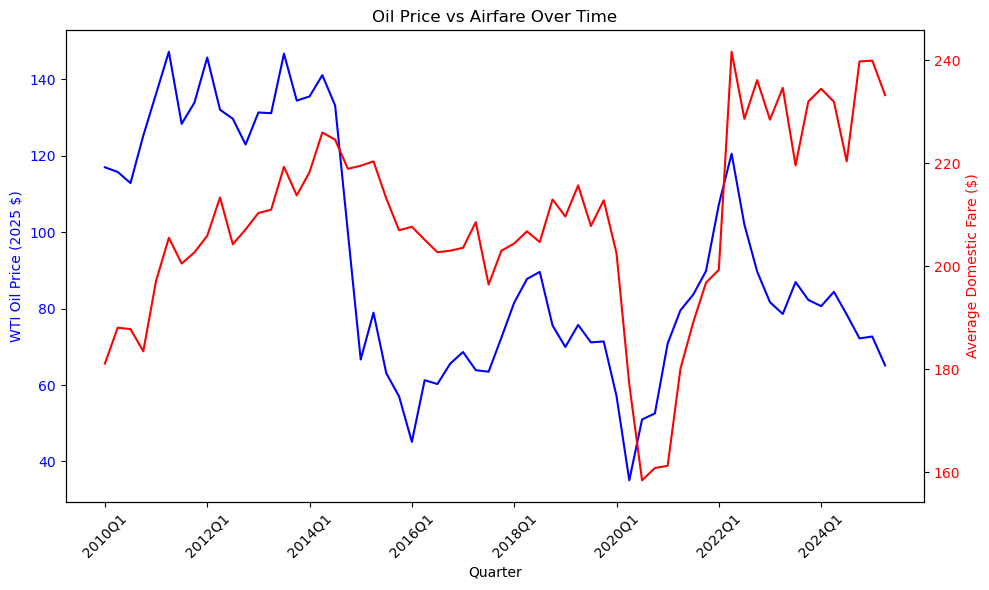

In [ ]:
# Visualization 1: Dual-Axis Line Plot: Oil vs Airfare Over Time

dataset_a_sorted = dataset_a.sort_values('quarter').reset_index(drop=True)

# widen for spacing
plt.figure(figsize=(10, 6))

# two y-axes bc oil prices and fares have different scales
ax1 = plt.gca()
ax2 = ax1.twinx()

# plot oil price on left axis
ax1.plot(dataset_a_sorted.index, dataset_a_sorted['wti_real_2025'], 
         'b-', label='WTI Oil Price')
ax1.set_xlabel('Quarter')
ax1.set_ylabel('WTI Oil Price (2025 $)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# plot airfare on right axis
ax2.plot(dataset_a_sorted.index, dataset_a_sorted['avg_domestic_fare'], 
         'r-', label='Avg Domestic Fare')
ax2.set_ylabel('Average Domestic Fare ($)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# show quarter labels every 8th quarter so it's not too crowded
tick_positions = range(0, len(dataset_a_sorted), 8)
tick_labels = [dataset_a_sorted.loc[i, 'quarter'] for i in tick_positions]
ax1.set_xticks(tick_positions)
ax1.set_xticklabels(tick_labels, rotation=45)

plt.title('Oil Price vs Airfare Over Time')
plt.tight_layout()
plt.savefig('visualization_1_oil_vs_airfare.png', dpi=300, bbox_inches='tight')
plt.show()

### Visualization 1 Explanation

This dual-axis time series plot shows WTI Oil Prices (blue, left axis) and Average Domestic Airfares (red, right axis) from 2010 to 2025. Oil prices are highly volatile with sharp spikes, especially from 2010-2014, while airfares stay relatively stable except for the big drop in 2020 (probably COVID-19). This confirms that airfare prices are pretty sticky - they don't move much even when oil prices swing wildly. Airlines might be hedging against oil price changes, or they're pricing based more on demand and competition than fuel costs. 

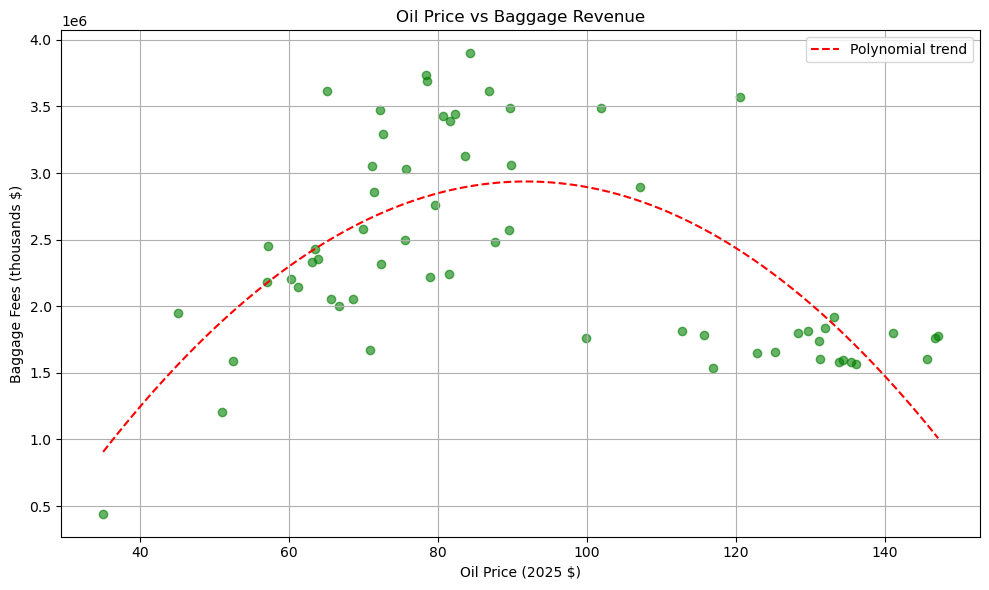

In [ ]:
# Visualization 2: Scatter Plot with Polynomial Trendline: Oil vs Baggage Revenue

# widen for spacing
plt.figure(figsize=(10, 6))

plt.scatter(dataset_a['wti_real_2025'], dataset_a['total_baggage_fees'], alpha=0.6, color='green')

# polynomial trendline (degree 2) to match Insight 2
z = np.polyfit(dataset_a['wti_real_2025'], dataset_a['total_baggage_fees'], 2)
p = np.poly1d(z)
x_smooth = np.linspace(dataset_a['wti_real_2025'].min(), dataset_a['wti_real_2025'].max(), 100)
plt.plot(x_smooth, p(x_smooth), 'r--', label='Polynomial trend')

plt.xlabel('Oil Price (2025 $)')
plt.ylabel('Baggage Fees (thousands $)')
plt.title('Oil Price vs Baggage Revenue')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('visualization_2_oil_vs_baggage.png', dpi=300, bbox_inches='tight')
plt.show()

### Visualization 2 Explanation

This scatter plot shows the relationship between real oil prices (x-axis) and total baggage fees (y-axis). The red dashed curve is a polynomial trendline (degree 2) that matches the model from Insight 2. The curve shows a non-linear relationship - baggage fees seem to follow a curved pattern rather than a straight line as oil prices change. There's still a lot of scatter around the curve, which shows the relationship isn't super strong and other factors matter too. 

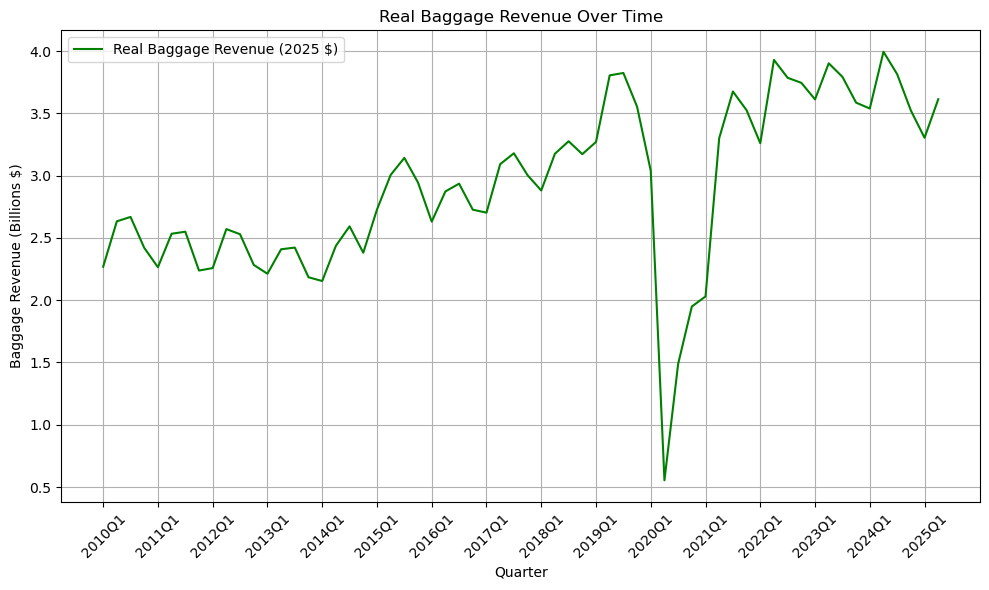

In [ ]:
# Visualization 3: Line Plot: Real Baggage Revenue Over Time
# Note: Requires Insight 5 to be run first (creates revenue_billions column)

# widen for spacing
plt.figure(figsize=(10, 6))

plt.plot(dataset_a['quarter'], dataset_a['revenue_billions'], 'g-', label='Real Baggage Revenue (2025 $)')

plt.xlabel('Quarter')
plt.ylabel('Baggage Revenue (Billions $)')
plt.title('Real Baggage Revenue Over Time')

# show every 4th quarter on x-axis
plt.xticks(dataset_a['quarter'][::4], rotation=45)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('visualization_3_baggage_revenue_time.png', dpi=300, bbox_inches='tight')
plt.show()

### Visualization 3 Explanation

This line chart tracks total real baggage revenue (adjusted for inflation to 2025 dollars). The graph shows a clear upward trend from 2010 through 2025, which shows airlines are increasingly relying on baggage fees as a revenue source. You can also see the jagged peaks and valleys showing seasonal patterns that match high and low travel quarters. There's a big dip in 2020 (probably from COVID-19), but it looks like the industry has mostly recovered since then. 

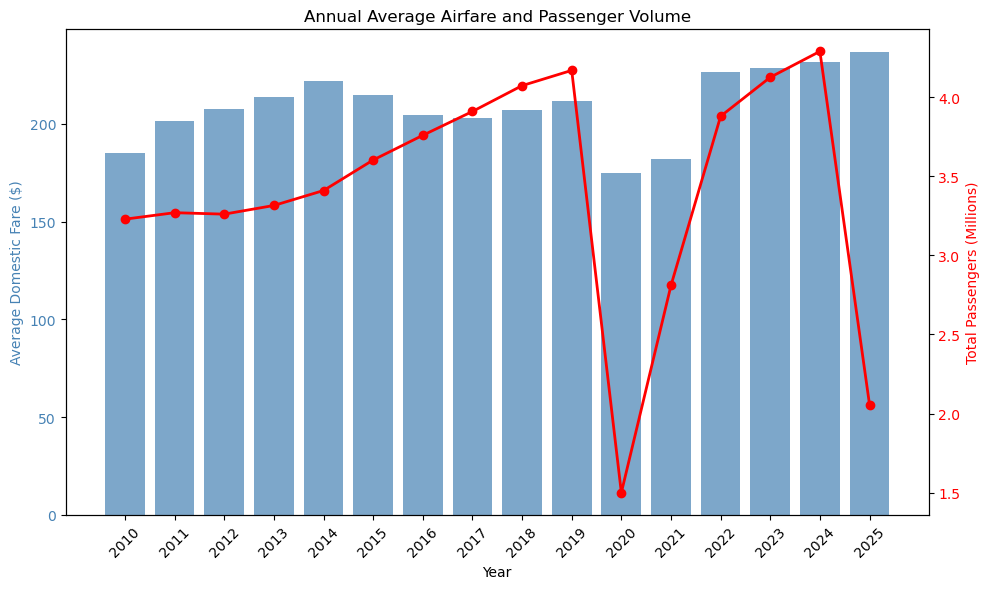

In [ ]:
# Visualization 4: Bar Chart: Average Annual Airfare vs Passenger Volume

# extract year from quarter and aggregate by year
dataset_a['year'] = dataset_a['quarter'].str[:4].astype(int)
yearly_data = dataset_a.groupby('year').agg({
    'avg_domestic_fare': 'mean',
    'total_passengers': 'sum'
}).reset_index()

# widen for spacing
fig, ax1 = plt.subplots(figsize=(10, 6))

# bar chart for average fare on left axis
ax1.bar(yearly_data['year'], yearly_data['avg_domestic_fare'], color='steelblue', alpha=0.7)
ax1.set_xlabel('Year')
ax1.set_ylabel('Average Domestic Fare ($)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(yearly_data['year'])
ax1.set_xticklabels(yearly_data['year'], rotation=45)

# add passenger volume on right axis
ax2 = ax1.twinx()
ax2.plot(yearly_data['year'], yearly_data['total_passengers'] / 1000000, 
         'ro-', linewidth=2, markersize=6, label='Total Passengers (Millions)')
ax2.set_ylabel('Total Passengers (Millions)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Annual Average Airfare and Passenger Volume')
plt.tight_layout()
plt.savefig('visualization_4_annual_fare_passengers.png', dpi=300, bbox_inches='tight')
plt.show()

# cleanup temp column
dataset_a = dataset_a.drop('year', axis=1)

### Visualization 4 Explanation

This bar chart compares average annual airfares (blue bars) with total passenger volume (red line) from 2010 to 2025. We included this visualization to diversify our presentation and to show the relationship between demand and pricing from a different perspective. The bars show that average fares stayed relatively stable over time with a notable drop in 2020, while the passenger volume overlay reveals a strong recovery in travel demand post-2020. This suggests that even as passenger numbers rebounded, airlines maintained competitive pricing rather than significantly increasing fares, which supports the demand-based pricing insight from our Random Forest analysis.

# Cited Sources

If you used any additional sources to complete your Data Analysis section, list them here:

* All lecture docs, per links on the Living Google Sheet Schedule
* [NumPy array manipulation routines](https://numpy.org/doc/stable/reference/routines.array-manipulation.html)
* [Matplotlib `scatter` function reference](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html)
* [Python `re` module documentation](https://docs.python.org/3/library/re.html)
* [Requests library documentation](https://requests.readthedocs.io/en/latest/)
* [scikit-learn `LinearRegression` class documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
* [scikit-learn `RandomForestRegressor` documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)
* [scikit-learn `PolynomialFeatures` documentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)
* [scikit-learn `train_test_split` documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
* [Matplotlib pyplot twinx method + more](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.twinx.html)
* [Beautiful Soup 4 documentation](https://www.crummy.com/software/BeautifulSoup/bs4/doc/)
* [Matplotlib pyplot tutorial](https://matplotlib.org/stable/tutorials/pyplot.html)


